# WGU Capstone Project: Numerical Weather Prediction Analysis
This Juypter notebook is used to perform the feature engineering, model training, and evaluation of several models for predicting Numerical Weather data.
The data is ingested from an InfluxDB bucket that pulls archived weather data from the OpenMeteo API. The data is stored in a bucket named `OpenMeteo` and is stored in hourly summaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from weather_utils import fetch_influx_data, engineer_features

df_raw = fetch_influx_data()
print(f"Data loaded. Shape: {df_raw.shape}")
print(f"Locations: {df_raw['location'].unique()}")
df_raw.head()

Data loaded. Shape: (52500, 20)
Locations: <StringArray>
['dubois', 'lander', 'pinedale']
Length: 3, dtype: str


,time,day_of_week,location,month_name,season,cloud_cover,cloud_cover_high,cloud_cover_low,cloud_cover_mid,hour,is_weekend,month,precipitation,rain,relative_humidity,snow_depth,snowfall,temperature,wind_speed,year
23922,2024-03-17 02:00:00+00:00,Sunday,dubois,Mar,spring,5.0,0.0,5.0,0.0,2,1,3,0.0,0.0,61.773895,0.83,0.0,1.603500,8.534353,2024
23923,2024-03-17 03:00:00+00:00,Sunday,dubois,Mar,spring,18.0,0.0,17.0,8.0,3,1,3,0.0,0.0,63.055996,0.83,0.0,1.053500,5.692099,2024
23924,2024-03-17 04:00:00+00:00,Sunday,dubois,Mar,spring,49.0,0.0,27.0,46.0,4,1,3,0.0,0.0,72.050041,0.83,0.0,-1.046500,2.620839,2024
23925,2024-03-17 05:00:00+00:00,Sunday,dubois,Mar,spring,63.0,16.0,25.0,52.0,5,1,3,0.0,0.0,85.646194,0.83,0.0,-6.896500,1.938659,2024
23926,2024-03-17 06:00:00+00:00,Sunday,dubois,Mar,spring,43.0,8.0,36.0,22.0,6,1,3,0.0,0.0,87.949974,0.83,0.0,-7.596499,3.319036,2024


### Initial Data Investigation and Tests
Identify the date range, shape, and missingness for key fields.

In [2]:
print("Date range:", df_raw["time"].min(), "→", df_raw["time"].max())
print("Rows per location:")
print(df_raw["location"].value_counts())

key_fields = [
    "temperature",
    "precipitation",
    "wind_speed",
    "relative_humidity",
    "cloud_cover",
    "rain",
    "snowfall",
]
available = [col for col in key_fields if col in df_raw.columns]
if available:
    print("\nMissing values by field:")
    print(df_raw[available].isna().mean().sort_values(ascending=False))

Date range: 2024-03-17 02:00:00+00:00 → 2026-03-16 05:00:00+00:00
Rows per location:
location
dubois      17500
lander      17500
pinedale    17500
Name: count, dtype: int64

Missing values by field:
temperature          0.0
precipitation        0.0
wind_speed           0.0
relative_humidity    0.0
cloud_cover          0.0
rain                 0.0
snowfall             0.0
dtype: float64


### Feature Engineering

Prior to training this step will engineer features to capture temporal trends, lagged features, and rolling statistics to aid in model training.
1.  **Temporal Features**: Extract hour, day, month from timestamp
2.  **Lagged Features**: Use past values (e.g., 1h, 3h, 6h ago) to predict future values
3.  **Rolling Statistics**: Moving averages and standard deviations to capture trends
4. **One-Hot Encoding Categorical Features**: Convert day_of_week, month_name, and season to numerical values


In [3]:
df_engineered = engineer_features(df_raw)
print(f"Feature Engineering complete. Shape: {df_engineered.shape}")

Feature Engineering complete. Shape: (52428, 131)


### Feature Selection & Correlation
Let's look at how features correlate with our targets. This is merely a snapshot of the features and does not prove causality.

I have also excluded `time` and `location` from the correlation matrix to avoid trivial correlations.


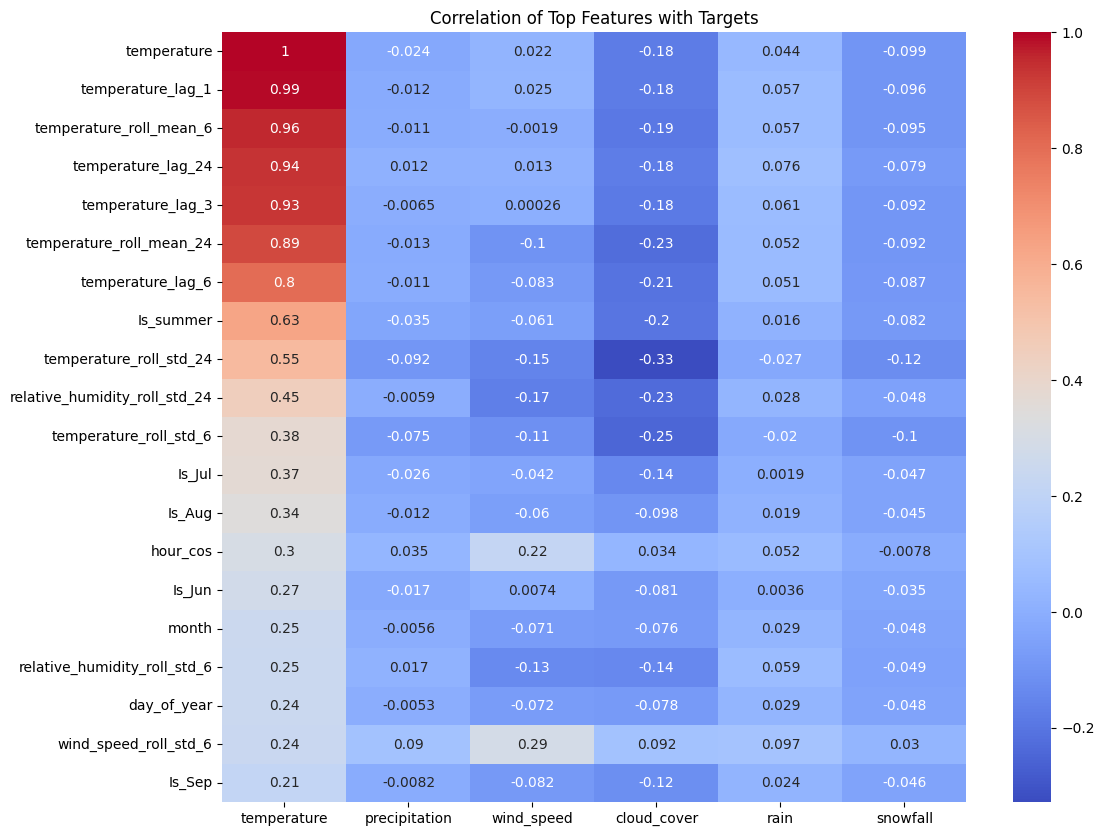

In [4]:
targets = ['temperature', 'precipitation', 'wind_speed', 'cloud_cover', 'rain', 'snowfall']

corr_matrix = df_engineered.drop(columns=['time', 'location']).corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[targets].sort_values(by=targets, ascending=False).head(20), annot=True, cmap='coolwarm')
plt.title("Correlation of Top Features with Targets")
plt.show()

The correlation matrix calculated as shown above offers insights into what we may come to expect from this type of numerical modeling.
For example, the temperature-lagged features are of high importance and likely are correlated. Though features like Cloud_Cover, and wind_speed will be challenging to infer/predict based on the current set of features.
The higher precipitation values, as shown for rain_roll_std_6 rain_roll_mean_6, may be of use for predicting Precipitation, or rain likelihood, as it will be challenging to predict rain likelihood without including radar data.

### Model Training
Five models will be used for training, and the best performing model will be used for future predictions
- Random forests handle nonlinear relationships and mixed feature types well
- Gradient Boosting Machines (GBM) are known for their ability to handle complex interactions and are often used for regression tasks
- Ridge regression is a linear regression model that attempts to minimize the L2 norm of the residuals
- XGBoost is a fast, scalable, and effective gradient-boosting library that can handle large datasets and complex interactions
- LightGBM is a fast, scalable gradient boosting framework that provides a more efficient and flexible alternative to XGBoost

**Important:** We split **chronologically** (shuffle=False) to avoid future data leaking into the training set.


In [5]:
# 1. Define Features and Targets
drop_cols = ['time', 'location'] + targets
X = df_engineered.drop(columns=drop_cols)
y = df_engineered[targets]

# We use pd.get_dummies, ensuring all expected locations are present
X = pd.concat([X, pd.get_dummies(df_engineered['location'], prefix='loc')], axis=1)

# Check: only numeric data is in X
X = X.select_dtypes(include=[np.number, bool])

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Definitions
models = {
    "Random Forest": MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    "LightGBM": MultiOutputRegressor(LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
}

# 5. Fit Models
for name, model in models.items():
    print(f"Training {name} model...")
    model.fit(X_train, y_train)
    print(f"Training {name} complete.")

# 6. Save models to a pickle file
with open('models.pickle', 'wb') as f:
    pickle.dump(models, f)
    print("Models saved to models.pickle")

Training Random Forest model...
Training Random Forest complete.
Training Linear Regression model...
Training Linear Regression complete.
Training Ridge Regression model...
Training Ridge Regression complete.
Training XGBoost model...
Training XGBoost complete.
Training LightGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17837
[LightGBM] [Info] Number of data points in the train set: 41942, number of used features: 126
[LightGBM] [Info] Start training from score 6.962898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17837
[LightGBM] [Info] Number of data points in the train set: 41942, number of used features: 126
[LightGBM] [

### Model Evaluation
With the models successfully trained, the next step is to evaluate their performance, in this case we can use the Root Mean Squared Error (RMSE) and R² Score for each target.

In [6]:
from collections import namedtuple
import pandas as pd

Score = namedtuple('Score', 'model target rmse r2 stdev')
all_scores = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    for i, target in enumerate(targets):
        rmse = root_mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        stdev = np.std(y_test.iloc[:, i])
        all_scores.append(Score(name, target, rmse, r2, stdev))

# Create a DataFrame for easier comparison
scores_df = pd.DataFrame(all_scores)

# Display scores
for name in models.keys():
    print(f"\n--- {name} Performance ---")
    model_scores = scores_df[scores_df['model'] == name]
    for _, score in model_scores.iterrows():
        print(f"rmse={score.rmse:.2f}, r2={score.r2:.2f}, stdev={score.stdev:.2f} | {score.target}")

# Summary Comparison for a key target (e.g., Temperature)
print("\n--- Model Comparison (Temperature) ---")
temp_comparison = scores_df[scores_df['target'] == 'temperature'].sort_values('rmse')
print(temp_comparison[['model', 'rmse', 'r2']])


--- Random Forest Performance ---
rmse=0.68, r2=1.00, stdev=10.68 | temperature
rmse=0.18, r2=0.51, stdev=0.25 | precipitation
rmse=2.50, r2=0.89, stdev=7.57 | wind_speed
rmse=1.58, r2=1.00, stdev=42.28 | cloud_cover
rmse=0.13, r2=0.53, stdev=0.18 | rain
rmse=0.07, r2=0.53, stdev=0.10 | snowfall

--- Linear Regression Performance ---
rmse=0.56, r2=1.00, stdev=10.68 | temperature
rmse=0.19, r2=0.41, stdev=0.25 | precipitation
rmse=2.64, r2=0.88, stdev=7.57 | wind_speed
rmse=10.91, r2=0.93, stdev=42.28 | cloud_cover
rmse=0.14, r2=0.38, stdev=0.18 | rain
rmse=0.08, r2=0.44, stdev=0.10 | snowfall

--- Ridge Regression Performance ---
rmse=0.56, r2=1.00, stdev=10.68 | temperature
rmse=0.19, r2=0.40, stdev=0.25 | precipitation
rmse=2.64, r2=0.88, stdev=7.57 | wind_speed
rmse=10.91, r2=0.93, stdev=42.28 | cloud_cover
rmse=0.14, r2=0.38, stdev=0.18 | rain
rmse=0.08, r2=0.43, stdev=0.10 | snowfall

--- XGBoost Performance ---
rmse=0.65, r2=1.00, stdev=10.68 | temperature
rmse=0.17, r2=0.55, st

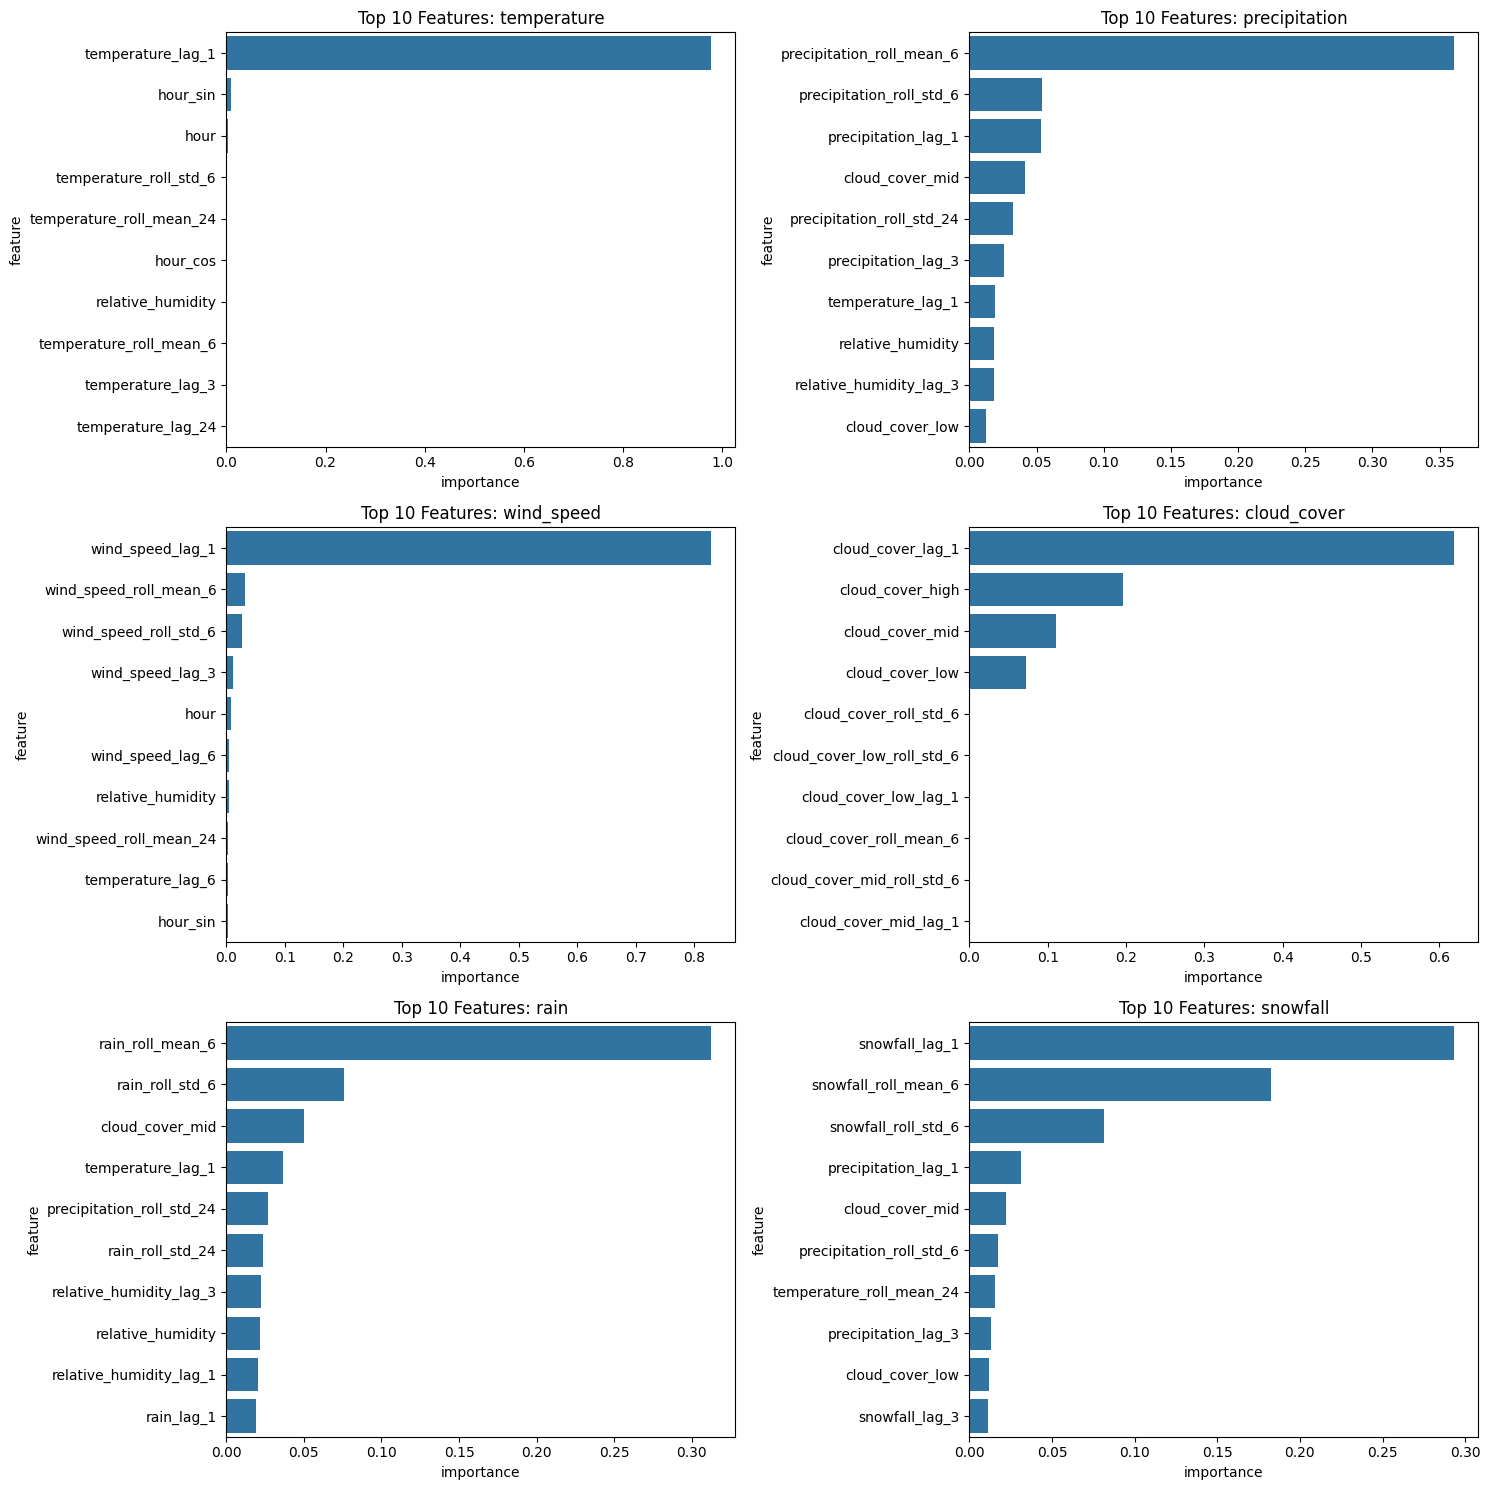

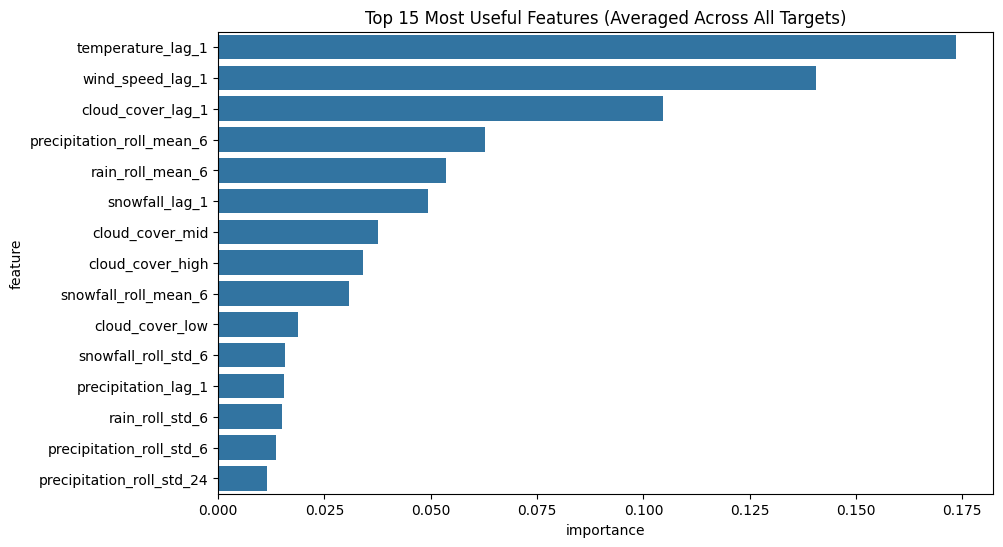

In [7]:
# Feature Importance for the Random Forest Model (Per Target)
rf_model = models["Random Forest"]

# Extract importance per target
importance_data = []
for i, target in enumerate(targets):
    # rf_model.estimators_[i] is the RandomForestRegressor for that target
    importances = rf_model.estimators_[i].feature_importances_
    for feat, imp in zip(X.columns, importances):
        importance_data.append({'target': target, 'feature': feat, 'importance': imp})

importance_df = pd.DataFrame(importance_data)

# 1. Visualizing Top Features per Target (Subplots)
num_targets = len(targets)
fig, axes = plt.subplots(nrows=(num_targets + 1) // 2, ncols=2, figsize=(15, 5 * ((num_targets + 1) // 2)))
axes = axes.flatten()

for i, target in enumerate(targets):
    top_features = importance_df[importance_df['target'] == target].sort_values('importance', ascending=False).head(10)
    sns.barplot(x='importance', y='feature', data=top_features, ax=axes[i])
    axes[i].set_title(f"Top 10 Features: {target}")

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2. Aggregated Feature Importance (Mean across all targets)
agg_importance = importance_df.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=agg_importance.head(15))
plt.title("Top 15 Most Useful Features (Averaged Across All Targets)")
plt.show()

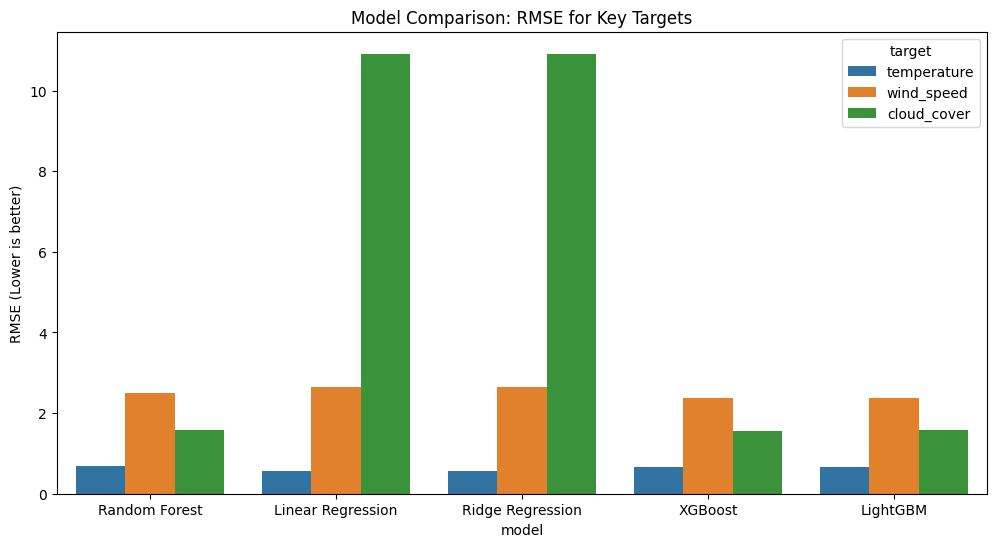

In [8]:
# Model Performance Comparison Plot (RMSE)
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='rmse', hue='target', data=scores_df[scores_df['target'].isin(['temperature', 'wind_speed', 'cloud_cover'])])
plt.title("Model Comparison: RMSE for Key Targets")
plt.ylabel("RMSE (Lower is better)")
plt.show()

The results shown above represent the model's relative performance across different targets. The RMSE values indicate the average prediction error for each model and target combination. Lower RMSE values suggest better model performance. The plot provides a visual comparison of how well each model predicts temperature, wind speed, and cloud cover, which are key weather variables for our analysis, considering the previous feature important output

### Collecting model metrics over different forecast horizons (h)
The next step is to evaluate the model's performance over different forecast horizons (h).
This will help build an understanding of how accurate future forecasts will be over different forecast horizons.

In [9]:
# Evaluate performance metrics across different forecast horizons (h)
horizons = [1, 2, 3, 6, 12, 24, 32, 40, 48]

# 1) collect the engineered weather data
def evaluate_horizon(h, df_engineered):
    # 2) shift the dataset by the time horizon
    y = df_engineered['temperature'].shift(-h).dropna()
    # 3) collect the accurate values within the time horizon
    X = df_engineered.drop(columns=['temperature']).iloc[:-h]

    # 4) Encode the categorical variables as numerical values
    X = pd.concat([X.drop(columns=['location', 'time']), pd.get_dummies(X['location'], prefix='loc')], axis=1)
    X = X.select_dtypes(include=[np.number, bool])

    # 5) Split into train and test
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # 6) Train Random Forest
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
    model.fit(X_train, y_train)

    # 7) Collect model error and variance metrics
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return {'Horizon': h, 'MAE': mae, 'RMSE': rmse, "R2": r2, "Model": "Random Forest"}

# Execute in parallel
results = Parallel(n_jobs=-1)(delayed(evaluate_horizon)(h, df_engineered) for h in horizons)

# Convert to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

   Horizon       MAE      RMSE        R2          Model
0        1  0.807904  1.085506  0.989663  Random Forest
1        2  1.052758  1.391526  0.983012  Random Forest
2        3  1.243044  1.641547  0.976360  Random Forest
3        6  1.720874  2.268983  0.954836  Random Forest
4       12  1.999126  2.631198  0.939267  Random Forest
5       24  2.210076  2.971708  0.922542  Random Forest
6       32  2.454802  3.267518  0.906357  Random Forest
7       40  2.566419  3.404415  0.898351  Random Forest
8       48  2.570737  3.397168  0.898784  Random Forest


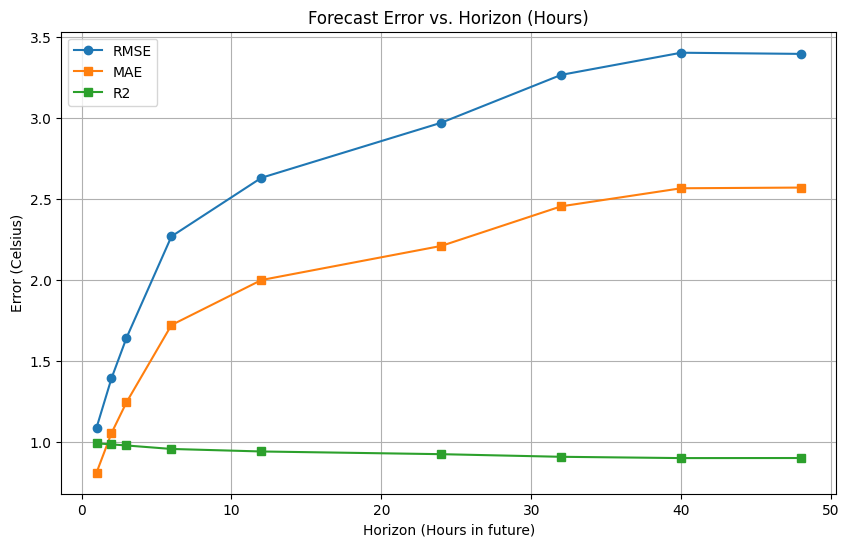

In [10]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['Horizon'], results_df['RMSE'], marker='o', label='RMSE')
plt.plot(results_df['Horizon'], results_df['MAE'], marker='s', label='MAE')
plt.plot(results_df['Horizon'], results_df['R2'], marker='s', label='R2')
plt.title('Forecast Error vs. Horizon (Hours)')
plt.xlabel('Horizon (Hours in future)')
plt.ylabel('Error (Celsius)')
plt.grid(True)
plt.legend()
plt.show()